# Section 1.2.5 — Deuxièmes limites avec Markovian Conditional Restart Splitting

On étend le modèle aux deux premières limites de chaque côté du carnet :

$$
Q^{+1}, Q^{+2}\quad \text{côté ask},\qquad
Q^{-1}, Q^{-2}\quad \text{côté bid}.
$$

Cette version utilise **Markovian Conditional Restart Splitting** (MCRS). Ogata thinning reste le simulateur de trajectoires sous-jacent, mais les estimateurs conditionnels redémarrent depuis des checkpoints markoviens complets $(N,S)$, avec burn-in Hawkes.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model.hawkes_4q import FourQueueParams
from model import FourQueueHawkesSimulator
from model.restart_splitting import (
    METHOD_NAME,
    bootstrap_difference_ci,
    bootstrap_mean_ci,
    collect_boundary_states,
    default_hawkes_burn_in,
    local_depletion_target_fn,
    local_recovery_fn,
    multilevel_markovian_restart_splitting,
    plot_conditional_S_marginals,
    plot_conditional_S_pairwise,
    restart_from_boundary_distribution,
    run_naive_depletion_monte_carlo,
    summarize_conditional_S,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

SEED = 42
QUEUE_INDICES = [1, -1, 2, -2]

BASE_CFG = dict(
    mu_plus_1=1.2,
    mu_minus_1=1.5,
    alpha=0.3,
    beta=0.5,
    mu_plus_2=0.8,
    mu_minus_2=0.6,
    b_cross=0.5,
    q1_init=10,
    q_neg1_init=10,
    q2_init=5,
    q_neg2_init=5,
)

A_VALUES = [0.0, 0.2, 0.5, 0.8, 1.2]
LEVELS = [8, 6, 4, 2, 1, 0]
N_BOUNDARY_PATHS = 300
N_RESTARTS = 1_000
HORIZON_BOUNDARY = 120.0
HORIZON_LOCAL = 25.0
RECOVERY_LEVEL = 2
BOOTSTRAP_REPS = 1_000

# The default implemented in model/restart_splitting.py is 10 / (beta * (1 - alpha / beta)).
BURN_IN = default_hawkes_burn_in(FourQueueHawkesSimulator(FourQueueParams(**BASE_CFG, a_cross=0.0)))

pd.Series({**BASE_CFG, 'burn_in': BURN_IN, 'method': METHOD_NAME}, name='configuration')

mu_plus_1                                          1.2
mu_minus_1                                         1.5
alpha                                              0.3
beta                                               0.5
mu_plus_2                                          0.8
mu_minus_2                                         0.6
b_cross                                            0.5
q1_init                                             10
q_neg1_init                                         10
q2_init                                              5
q_neg2_init                                          5
burn_in                                           50.0
method         Markovian Conditional Restart Splitting
Name: configuration, dtype: object

## Convention de signe et état markovien augmenté

Le code utilise l'ordre d'état suivant :

$$[Q^{+1}, Q^{-1}, Q^{+2}, Q^{-2}].$$

Les indices positifs correspondent au côté ask, les indices négatifs au côté bid. Les objets estimés sont :

- $Q^{-2}_{same}=Q^{-2}\mid Q^{-1}=0$ ;
- $Q^{-2}_{opp}=Q^{-2}\mid Q^{+1}=0$ ;
- $\mathrm{Law}(Q^{-2}\mid Q^{-1}=0)$ ;
- $\mathrm{Law}(Q^{-2}\mid Q^{+1}=0)$.

Le vecteur d'excitation extrait des checkpoints quatre files est maintenant :

$$
S=(S^{+1,-}, S^{-1,-}, S^{+1,-\to +2,+}, S^{-1,-\to -2,+}).
$$

Il n'y a plus de duplication artificielle de $G_{-2}$ : $G_{+2}$ est exposé comme $S^{+1,-\to +2,+}$ et $G_{-2}$ comme $S^{-1,-\to -2,+}$.

In [2]:
def make_params(a_cross: float, q0: int = 10) -> FourQueueParams:
    return FourQueueParams(
        **dict(BASE_CFG, q1_init=q0, q_neg1_init=q0),
        a_cross=float(a_cross),
    )


def q_label(queue_index: int) -> str:
    return 'Q+1' if queue_index == 1 else 'Q-1'


def resume_distribution(x):
    x = np.asarray(x, dtype=float)
    return pd.Series({
        'n': int(len(x)),
        'mean': float(np.mean(x)) if len(x) else np.nan,
        'std': float(np.std(x, ddof=1)) if len(x) > 1 else np.nan,
        'q05': float(np.quantile(x, 0.05)) if len(x) else np.nan,
        'median': float(np.quantile(x, 0.50)) if len(x) else np.nan,
        'q95': float(np.quantile(x, 0.95)) if len(x) else np.nan,
    })


def run_mcrs_side(
    params: FourQueueParams,
    queue_index: int,
    seed: int,
    n_boundary_paths: int = N_BOUNDARY_PATHS,
    n_restarts: int = N_RESTARTS,
    horizon_boundary: float = HORIZON_BOUNDARY,
    horizon_local: float = HORIZON_LOCAL,
    burn_in: float = BURN_IN,
):
    simulator = FourQueueHawkesSimulator(params)
    initial_state = [params.q1_init, params.q_neg1_init, params.q2_init, params.q_neg2_init]
    boundary_sample = collect_boundary_states(
        simulator=simulator,
        initial_state=initial_state,
        horizon=horizon_boundary,
        n_paths=n_boundary_paths,
        rng=seed,
        burn_in=burn_in,
        queue_index=queue_index,
        boundary_level=1,
        queue_indices=QUEUE_INDICES,
        boundary_name=f'{q_label(queue_index)}=1',
        queue_label=q_label(queue_index),
    )
    result = restart_from_boundary_distribution(
        checkpoints=boundary_sample,
        simulator=simulator,
        local_target_fn=local_depletion_target_fn(queue_index),
        recovery_fn=local_recovery_fn(queue_index, RECOVERY_LEVEL),
        horizon_local=horizon_local,
        n_restarts=n_restarts,
        rng=seed + 1_000_003,
        sample_with_replacement=True,
        record_path=False,
    )
    return {
        'method': METHOD_NAME,
        'params': params,
        'queue_index': queue_index,
        'simulator': simulator,
        'boundary_sample': boundary_sample,
        'result': result,
    }


def q_neg2_success(bundle):
    return np.asarray(bundle['result'].observables.get('q_neg2_success', np.empty(0)), dtype=float)


def conditional_S_table(sample):
    names = sample.metadata.get('S_component_names', [])
    summary = summarize_conditional_S(sample.S_samples, names)
    rows = []
    for j, name in enumerate(names):
        rows.append({
            'component': name,
            'mean': summary['mean'][j],
            'std': summary['std'][j],
            'q05': summary['quantiles'][0.05][j],
            'median': summary['quantiles'][0.50][j],
            'q95': summary['quantiles'][0.95][j],
        })
    return pd.DataFrame(rows).set_index('component') if rows else pd.DataFrame()


def restart_content_table(bundle, n=8):
    res = bundle['result']
    obs = res.observables
    names = bundle['boundary_sample'].metadata.get('S_component_names', [])
    rows = []
    for k in range(min(n, len(obs['success']))):
        row = {
            'restart': k,
            'outcome': obs['outcome'][k],
            'local_time': obs['local_times'][k],
            'start_Q+1': obs['start_queues'][k, 0],
            'start_Q-1': obs['start_queues'][k, 1],
            'start_Q-2': obs['start_queues'][k, 3],
            'final_Q+1': obs['final_queues'][k, 0],
            'final_Q-1': obs['final_queues'][k, 1],
            'final_Q-2': obs['final_queues'][k, 3],
        }
        for j, name in enumerate(names):
            row[f'start {name}'] = obs['start_S'][k, j]
            row[f'end {name}'] = obs['end_S'][k, j]
        rows.append(row)
    return pd.DataFrame(rows)


def estimator_row(regime, side_name, bundle, seed=SEED):
    res = bundle['result']
    sample = bundle['boundary_sample']
    diag = res.diagnostics
    q = q_neg2_success(bundle)
    mean_ci = bootstrap_mean_ci(q, n_bootstrap=BOOTSTRAP_REPS, rng=seed) if len(q) else (np.nan, np.nan)
    stats = resume_distribution(q)
    usage = diag.get('unique_checkpoint_usage_frequency', {})
    return {
        'a_cross': regime,
        'side': side_name,
        'method': res.method_name,
        'success_probability': diag.get('success_probability', res.probability_estimate),
        'recovery_probability': diag.get('recovery_probability', np.nan),
        'timeout_probability': diag.get('timeout_probability', np.nan),
        'std_error_success': res.standard_error,
        'n_boundary_samples': sample.metadata['n_boundary_hits'],
        'n_restarts': res.n_restarts,
        'n_successes': res.n_successes,
        'unique_checkpoints_used': len(usage),
        'max_checkpoint_reuse': max(usage.values()) if usage else 0,
        'checkpoint_usage_ess': diag.get('checkpoint_usage_effective_sample_size', np.nan),
        'avg_local_time': diag.get('average_local_simulation_time', np.nan),
        'acceptance_candidate_ratio': diag.get('acceptance_candidate_ratio', np.nan),
        'cpu_seconds': diag.get('cpu_seconds', np.nan),
        'mean_Q-2_success': stats['mean'],
        'std_Q-2_success': stats['std'],
        'q05_Q-2_success': stats['q05'],
        'median_Q-2_success': stats['median'],
        'q95_Q-2_success': stats['q95'],
        'mean_Q-2_ci_low': mean_ci[0],
        'mean_Q-2_ci_high': mean_ci[1],
    }


def plot_q_neg2_overlay(data, title):
    max_value = 10
    for values, _label in data:
        if len(values):
            max_value = max(max_value, int(np.max(values)))
    bins = np.arange(-0.5, max_value + 1.5, 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    for values, label in data:
        if len(values):
            ax.hist(values, bins=bins, density=True, alpha=0.42, label=label)
    ax.set_xlabel(r'$Q^{-2}$ at successful local depletion')
    ax.set_ylabel('density')
    ax.set_title(title)
    ax.legend()
    plt.show()


def plot_restart_scatter(bundle, title):
    res = bundle['result']
    obs = res.observables
    names = bundle['boundary_sample'].metadata.get('S_component_names', [])
    start_S = obs['start_S']
    final_q = obs['final_queues']
    success = obs['success']
    cross_name = 'S^{-1,- -> -2,+}'
    cross_idx = names.index(cross_name) if cross_name in names else start_S.shape[1] - 1
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(start_S[:, cross_idx], final_q[:, 3], c=success, cmap='coolwarm', alpha=0.55, s=18)
    ax.set_xlabel(f'start {names[cross_idx]}')
    ax.set_ylabel(r'final $Q^{-2}$')
    ax.set_title(title)
    plt.show()


## Boundary checkpoints with Hawkes burn-in

Boundary collection uses burn-in before the rare-event clock starts. With the current parameters

$$\alpha=0.3,\quad \beta=0.5,$$

we use

$$
T_{burn}=\frac{10}{\beta(1-\alpha/\beta)}=50.
$$

The empirical conditional laws below are therefore based on post-burn-in checkpoints.

In [3]:
params_ref = make_params(a_cross=0.5)
mcrs_ref_same = run_mcrs_side(params_ref, queue_index=-1, seed=SEED + 10)
mcrs_ref_opp = run_mcrs_side(params_ref, queue_index=1, seed=SEED + 20)

ref_table = pd.DataFrame([
    estimator_row(0.5, 'Q-1 boundary -> Q-2 same', mcrs_ref_same, seed=SEED + 101),
    estimator_row(0.5, 'Q+1 boundary -> Q-2 opp', mcrs_ref_opp, seed=SEED + 102),
])
display(ref_table)

display(pd.concat({
    'Law(S | Q-1=1)': conditional_S_table(mcrs_ref_same['boundary_sample']),
    'Law(S | Q+1=1)': conditional_S_table(mcrs_ref_opp['boundary_sample']),
}))


,a_cross,side,method,success_probability,recovery_probability,timeout_probability,std_error_success,n_boundary_samples,n_restarts,n_successes,...,avg_local_time,acceptance_candidate_ratio,cpu_seconds,mean_Q-2_success,std_Q-2_success,q05_Q-2_success,median_Q-2_success,q95_Q-2_success,mean_Q-2_ci_low,mean_Q-2_ci_high
0,0.5,Q-1 boundary -> Q-2 same,Markovian Conditional Restart Splitting,0.873,0.127,0.0,0.010530,300,1000,873,...,0.097967,0.969406,0.057489,83.126002,13.374550,63.0,82.0,108.4,82.221764,83.965636
1,0.5,Q+1 boundary -> Q-2 opp,Markovian Conditional Restart Splitting,0.863,0.137,0.0,0.010873,300,1000,863,...,0.110215,0.979089,0.061584,82.385863,13.854083,61.0,82.0,104.0,81.400811,83.285313


mean       std       q05    median  \
               component                                                  
Law(S | Q-1=1) S^{+1,-}          1.515757  0.775656  0.304396  1.475860   
               S^{-1,-}          1.701139  0.696575  0.713355  1.651115   
               S^{+1,- -> +2,+}  1.279093  0.615587  0.480615  1.199732   
               S^{-1,- -> -2,+}  1.401655  0.686404  0.434878  1.304557   
Law(S | Q+1=1) S^{+1,-}          1.757045  0.684875  0.668410  1.745146   
               S^{-1,-}          1.593878  0.799328  0.435685  1.523019   
               S^{+1,- -> +2,+}  1.493515  0.748092  0.509738  1.399453   
               S^{-1,- -> -2,+}  1.298921  0.576141  0.412945  1.299347   

                                      q95  
               component                   
Law(S | Q-1=1) S^{+1,-}          2.784230  
               S^{-1,-}          2.863328  
               S^{+1,- -> +2,+}  2.340151  
               S^{-1,- -> -2,+}  2.532080  
Law(S | Q+1=1) S^{+1,-}          2.896362  
               S^{-1,-}          3.082836  
               S^{+1,- -> +2,+}  2.803117  
               S^{-1,- -> -2,+}  2.287925

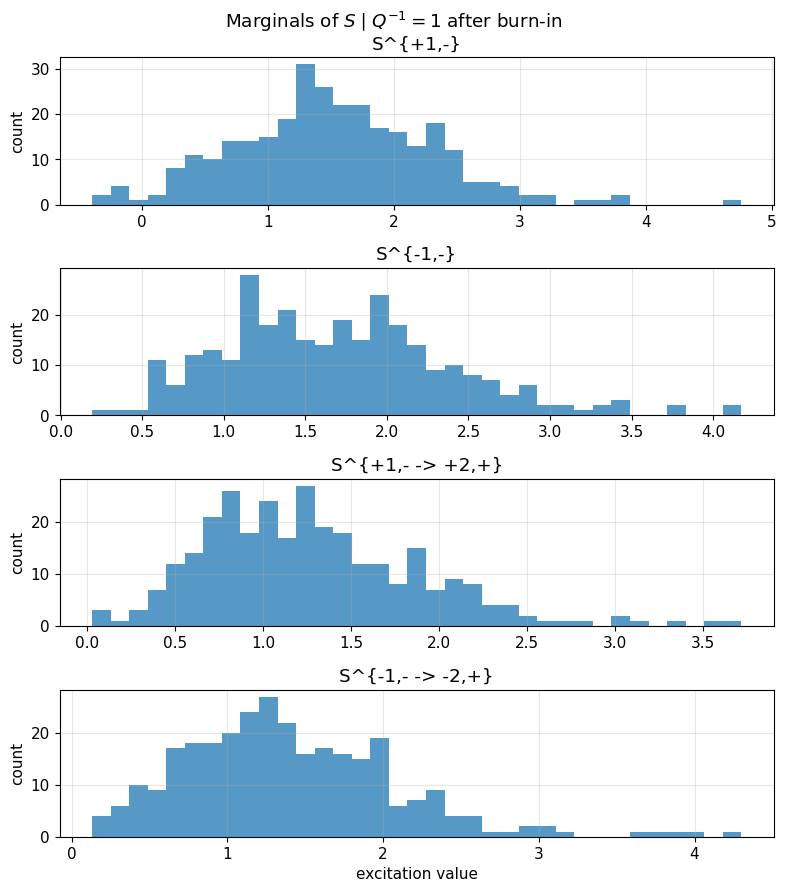

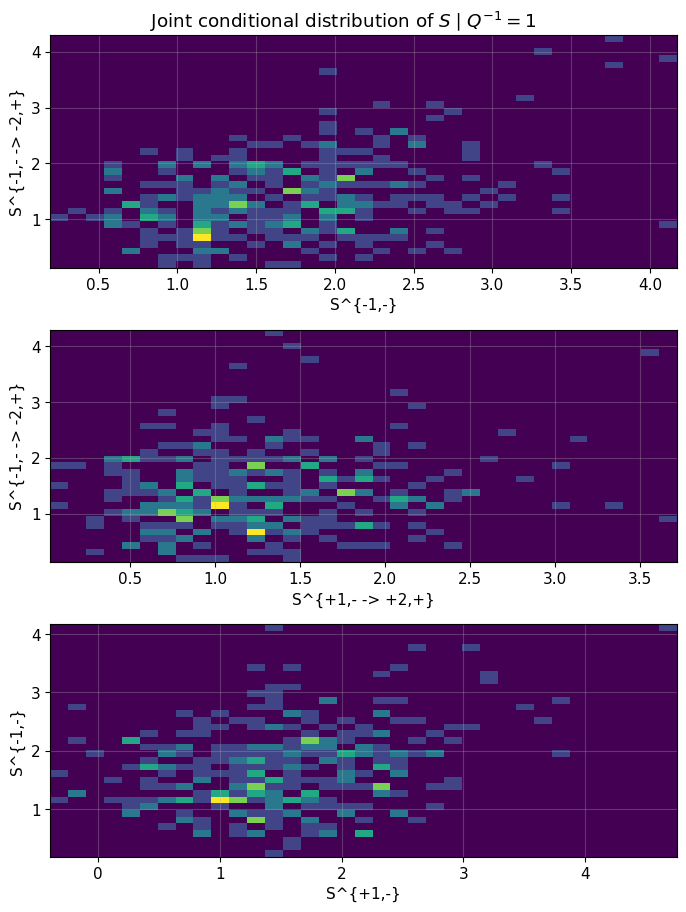

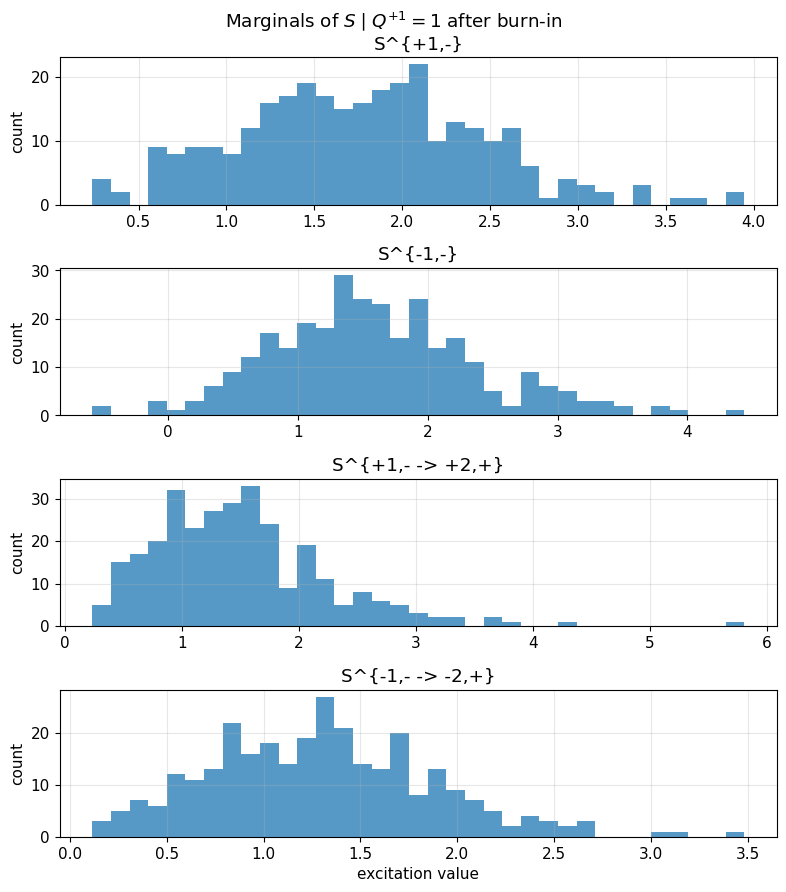

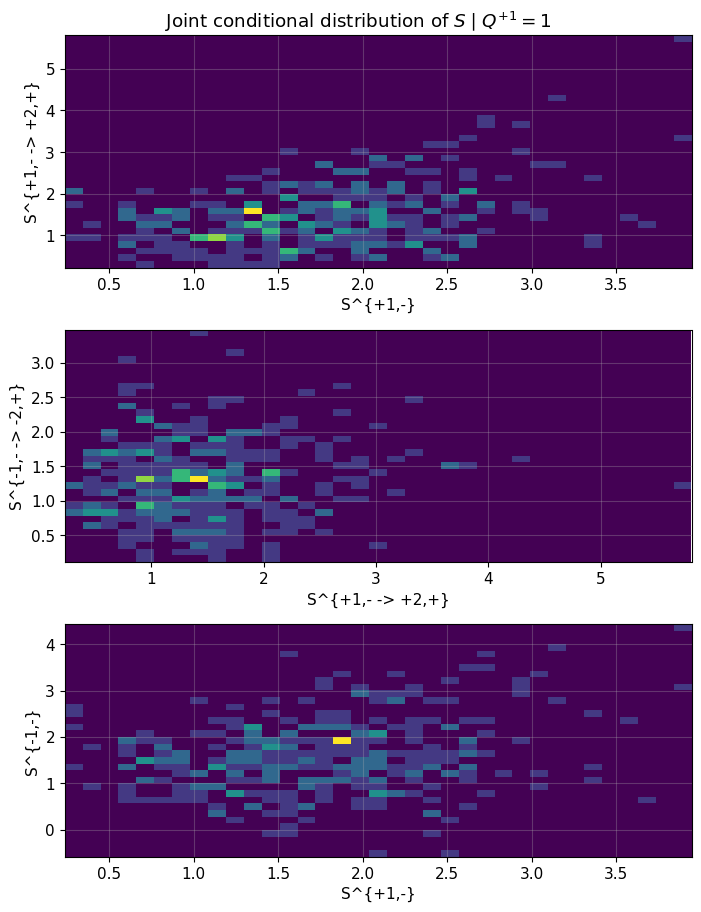

In [4]:
names_same = mcrs_ref_same['boundary_sample'].metadata['S_component_names']
names_opp = mcrs_ref_opp['boundary_sample'].metadata['S_component_names']

fig, _ = plot_conditional_S_marginals(mcrs_ref_same['boundary_sample'].S_samples, names_same, bins=35)
fig.suptitle(r'Marginals of $S\mid Q^{-1}=1$ after burn-in', y=1.01)
plt.show()

fig, _ = plot_conditional_S_pairwise(
    mcrs_ref_same['boundary_sample'].S_samples,
    names_same,
    pairs=[(1, 3), (2, 3), (0, 1)],
    bins=35,
)
fig.suptitle(r'Joint conditional distribution of $S\mid Q^{-1}=1$', y=1.01)
plt.show()

fig, _ = plot_conditional_S_marginals(mcrs_ref_opp['boundary_sample'].S_samples, names_opp, bins=35)
fig.suptitle(r'Marginals of $S\mid Q^{+1}=1$ after burn-in', y=1.01)
plt.show()

fig, _ = plot_conditional_S_pairwise(
    mcrs_ref_opp['boundary_sample'].S_samples,
    names_opp,
    pairs=[(0, 2), (2, 3), (0, 1)],
    bins=35,
)
fig.suptitle(r'Joint conditional distribution of $S\mid Q^{+1}=1$', y=1.01)
plt.show()


## Restart content and diagnostics

The table below shows actual restart samples. Each local path starts from a sampled boundary checkpoint containing queues, intensity, $H$, $G$, and the extracted $S$ components. Outcomes are classified as success, recovery, or timeout.

,restart,outcome,local_time,start_Q+1,start_Q-1,start_Q-2,final_Q+1,final_Q-1,final_Q-2,"start S^{+1,-}","end S^{+1,-}","start S^{-1,-}","end S^{-1,-}","start S^{+1,- -> +2,+}","end S^{+1,- -> +2,+}","start S^{-1,- -> -2,+}","end S^{-1,- -> -2,+}"
0,0,success,0.070262,0.0,1.0,84.0,0.0,0.0,84.0,1.621908,1.865918,0.949713,1.216928,0.993412,0.959119,1.149605,1.609919
1,1,recovery,0.353387,2.0,1.0,87.0,3.0,2.0,87.0,1.517365,1.305780,1.373082,1.116520,1.114973,0.934388,1.293733,1.084195
2,2,success,0.000000,1.0,0.0,95.0,1.0,0.0,95.0,0.213552,0.213552,1.776437,1.776437,1.444715,1.444715,0.213609,0.213609
3,3,success,0.454410,0.0,1.0,110.0,0.0,0.0,110.0,0.988172,1.087333,1.196910,1.253647,1.179839,0.940046,0.641062,1.010771
4,4,success,0.000000,4.0,0.0,89.0,4.0,0.0,89.0,0.296093,0.296093,2.226333,2.226333,0.946840,0.946840,1.155181,1.155181
5,5,success,0.062381,1.0,1.0,94.0,1.0,0.0,95.0,2.020642,2.258590,2.322024,2.550716,1.618577,1.568872,2.000311,2.438883
6,6,success,0.000000,2.0,0.0,88.0,2.0,0.0,88.0,0.153639,0.153639,1.147067,1.147067,0.291460,0.291460,0.792462,0.792462
7,7,success,0.000000,2.0,0.0,71.0,2.0,0.0,71.0,0.541668,0.541668,1.760499,1.760499,0.897611,0.897611,1.020862,1.020862


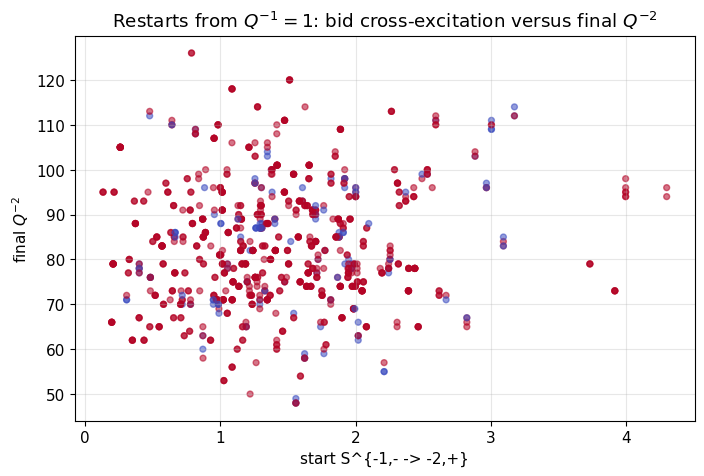

,side,success_probability,recovery_probability,timeout_probability,n_boundary_samples,unique_checkpoints_used,max_checkpoint_reuse,checkpoint_usage_ess,avg_local_time,acceptance_candidate_ratio,cpu_seconds
0,Q-1 boundary -> Q-2 same,0.873,0.127,0.0,300,289,9,229.252636,0.097967,0.969406,0.057489
1,Q+1 boundary -> Q-2 opp,0.863,0.137,0.0,300,287,9,230.733733,0.110215,0.979089,0.061584


In [5]:
display(restart_content_table(mcrs_ref_same, n=8))
plot_restart_scatter(
    mcrs_ref_same,
    r'Restarts from $Q^{-1}=1$: bid cross-excitation versus final $Q^{-2}$',
)

diagnostic_ref = ref_table[[
    'side',
    'success_probability',
    'recovery_probability',
    'timeout_probability',
    'n_boundary_samples',
    'unique_checkpoints_used',
    'max_checkpoint_reuse',
    'checkpoint_usage_ess',
    'avg_local_time',
    'acceptance_candidate_ratio',
    'cpu_seconds',
]]
display(diagnostic_ref)


## Sensitivity sweep in $a_{cross}$

For

$$A=\{0.0,0.2,0.5,0.8,1.2\},$$

we estimate both conditional laws

$$\mathrm{Law}(Q^{-2}\mid Q^{-1}=0),\qquad \mathrm{Law}(Q^{-2}\mid Q^{+1}=0),$$

including success/recovery/timeout probabilities and bootstrap confidence intervals for the conditional means.

In [6]:
sensitivity_rows = []
sensitivity_bundles = {}
diff_rows = []

for i, a in enumerate(A_VALUES):
    params = make_params(a_cross=a)
    same = run_mcrs_side(params, queue_index=-1, seed=SEED + 1_000 + 19 * i)
    opp = run_mcrs_side(params, queue_index=1, seed=SEED + 2_000 + 19 * i)
    sensitivity_bundles[a] = {'same': same, 'opp': opp}
    sensitivity_rows.append(estimator_row(a, 'Q-2 | Q-1=0 same-side', same, seed=SEED + 3_000 + i))
    sensitivity_rows.append(estimator_row(a, 'Q-2 | Q+1=0 opposite-side', opp, seed=SEED + 4_000 + i))

    q_same = q_neg2_success(same)
    q_opp = q_neg2_success(opp)
    diff_ci = bootstrap_difference_ci(q_same, q_opp, n_bootstrap=BOOTSTRAP_REPS, rng=SEED + 5_000 + i)
    diff_rows.append({
        'a_cross': a,
        'mean_same_minus_opp': np.mean(q_same) - np.mean(q_opp),
        'ci_low': diff_ci[0],
        'ci_high': diff_ci[1],
        'n_same': len(q_same),
        'n_opp': len(q_opp),
    })

sensitivity_table = pd.DataFrame(sensitivity_rows)
difference_table = pd.DataFrame(diff_rows)
display(sensitivity_table)
display(difference_table)


,a_cross,side,method,success_probability,recovery_probability,timeout_probability,std_error_success,n_boundary_samples,n_restarts,n_successes,...,avg_local_time,acceptance_candidate_ratio,cpu_seconds,mean_Q-2_success,std_Q-2_success,q05_Q-2_success,median_Q-2_success,q95_Q-2_success,mean_Q-2_ci_low,mean_Q-2_ci_high
0,0.0,Q-2 | Q-1=0 same-side,Markovian Conditional Restart Splitting,0.871,0.129,0.0,0.010600,300,1000,871,...,0.115238,0.980583,0.056639,15.509759,7.425311,3.0,15.0,28.0,15.042451,16.020666
1,0.0,Q-2 | Q+1=0 opposite-side,Markovian Conditional Restart Splitting,0.887,0.113,0.0,0.010012,300,1000,887,...,0.092863,0.983122,0.051695,14.329200,7.469568,2.0,14.0,28.0,13.820631,14.838839
2,0.2,Q-2 | Q-1=0 same-side,Markovian Conditional Restart Splitting,0.870,0.130,0.0,0.010635,300,1000,870,...,0.103811,0.979860,0.064613,42.383908,9.922007,27.0,41.0,60.0,41.721667,43.035920
3,0.2,Q-2 | Q+1=0 opposite-side,Markovian Conditional Restart Splitting,0.867,0.133,0.0,0.010738,300,1000,867,...,0.106050,0.976923,0.058048,42.802768,10.338903,26.0,42.0,60.0,42.123299,43.490283
4,0.5,Q-2 | Q-1=0 same-side,Markovian Conditional Restart Splitting,0.863,0.137,0.0,0.010873,300,1000,863,...,0.112576,0.978632,0.060664,84.273465,14.828543,60.0,84.0,109.0,83.275695,85.222798
5,0.5,Q-2 | Q+1=0 opposite-side,Markovian Conditional Restart Splitting,0.874,0.126,0.0,0.010494,300,1000,874,...,0.109936,0.968820,0.061484,82.589245,14.315522,58.0,82.0,106.0,81.644050,83.480606
6,0.8,Q-2 | Q-1=0 same-side,Markovian Conditional Restart Splitting,0.851,0.149,0.0,0.011261,300,1000,851,...,0.119074,0.977104,0.066804,120.045828,19.272633,88.5,119.0,154.5,118.709254,121.300676
7,0.8,Q-2 | Q+1=0 opposite-side,Markovian Conditional Restart Splitting,0.877,0.123,0.0,0.010386,300,1000,877,...,0.104839,0.974394,0.071389,121.319270,17.793225,93.0,121.0,150.0,120.096864,122.526226
8,1.2,Q-2 | Q-1=0 same-side,Markovian Conditional Restart Splitting,0.874,0.126,0.0,0.010494,300,1000,874,...,0.102534,0.971640,0.074601,176.854691,23.199137,136.0,177.0,215.0,175.271882,178.414960
9,1.2,Q-2 | Q+1=0 opposite-side,Markovian Conditional Restart Splitting,0.889,0.111,0.0,0.009934,300,1000,889,...,0.100529,0.978762,0.065363,176.944882,24.452710,138.4,176.0,218.0,175.368223,178.631440


,a_cross,mean_same_minus_opp,ci_low,ci_high,n_same,n_opp
0,0.0,1.180559,0.477248,1.887728,871,887
1,0.2,-0.418860,-1.353710,0.491384,870,867
2,0.5,1.684220,0.305171,3.021586,863,874
3,0.8,-1.273442,-2.921584,0.429397,851,877
4,1.2,-0.090191,-2.317871,2.100947,874,889


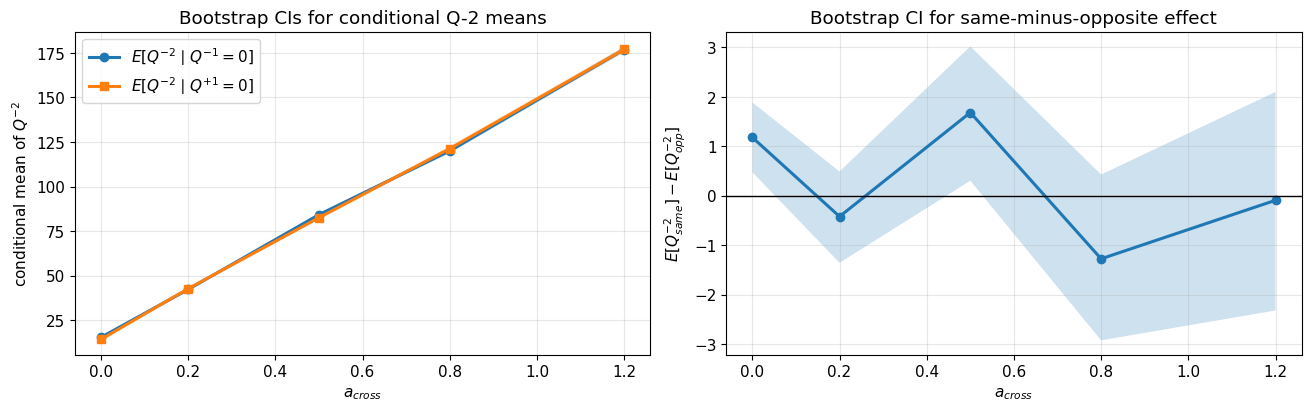

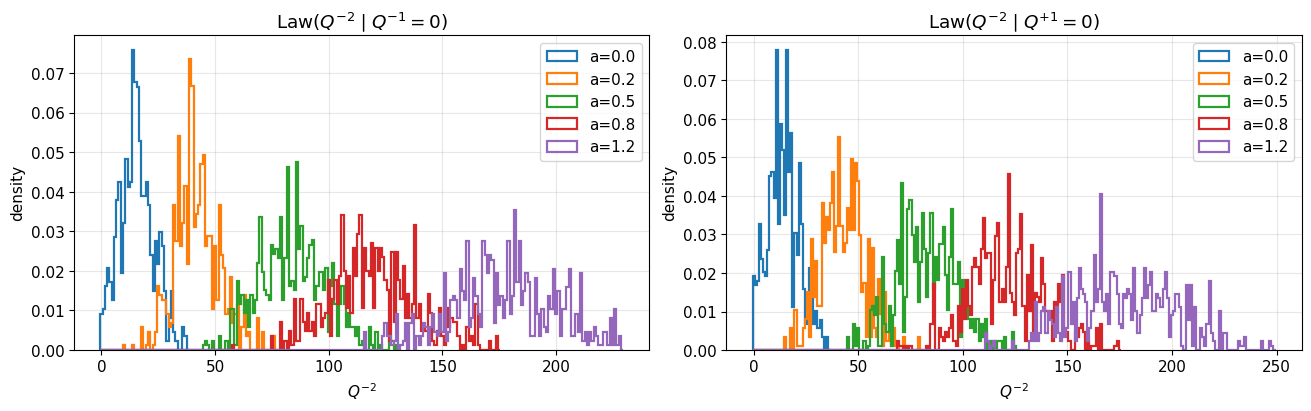

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout='constrained')
summary_same = sensitivity_table[sensitivity_table['side'] == 'Q-2 | Q-1=0 same-side']
summary_opp = sensitivity_table[sensitivity_table['side'] == 'Q-2 | Q+1=0 opposite-side']
axes[0].plot(summary_same['a_cross'], summary_same['mean_Q-2_success'], marker='o', linewidth=2.2, label=r'$E[Q^{-2}\mid Q^{-1}=0]$')
axes[0].fill_between(summary_same['a_cross'], summary_same['mean_Q-2_ci_low'], summary_same['mean_Q-2_ci_high'], alpha=0.18)
axes[0].plot(summary_opp['a_cross'], summary_opp['mean_Q-2_success'], marker='s', linewidth=2.2, label=r'$E[Q^{-2}\mid Q^{+1}=0]$')
axes[0].fill_between(summary_opp['a_cross'], summary_opp['mean_Q-2_ci_low'], summary_opp['mean_Q-2_ci_high'], alpha=0.18)
axes[0].set_xlabel(r'$a_{cross}$')
axes[0].set_ylabel(r'conditional mean of $Q^{-2}$')
axes[0].set_title('Bootstrap CIs for conditional Q-2 means')
axes[0].legend()

axes[1].plot(difference_table['a_cross'], difference_table['mean_same_minus_opp'], marker='o', linewidth=2.2)
axes[1].fill_between(difference_table['a_cross'], difference_table['ci_low'], difference_table['ci_high'], alpha=0.22)
axes[1].axhline(0.0, color='black', linewidth=1.0)
axes[1].set_xlabel(r'$a_{cross}$')
axes[1].set_ylabel(r'$E[Q^{-2}_{same}]-E[Q^{-2}_{opp}]$')
axes[1].set_title('Bootstrap CI for same-minus-opposite effect')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout='constrained')
for a, bundle in sensitivity_bundles.items():
    q_same = q_neg2_success(bundle['same'])
    q_opp = q_neg2_success(bundle['opp'])
    if len(q_same):
        axes[0].hist(q_same, bins=np.arange(-0.5, max(20, int(q_same.max()) + 2), 1), density=True, histtype='step', linewidth=1.6, label=f'a={a}')
    if len(q_opp):
        axes[1].hist(q_opp, bins=np.arange(-0.5, max(20, int(q_opp.max()) + 2), 1), density=True, histtype='step', linewidth=1.6, label=f'a={a}')
axes[0].set_title(r'$\mathrm{Law}(Q^{-2}\mid Q^{-1}=0)$')
axes[1].set_title(r'$\mathrm{Law}(Q^{-2}\mid Q^{+1}=0)$')
for ax in axes:
    ax.set_xlabel(r'$Q^{-2}$')
    ax.set_ylabel('density')
    ax.legend()
plt.show()


## Real multilevel Markovian restart splitting

We now add a true level-by-level splitting estimator. Starting from $Q_0=10$, particles are propagated through

$$[8,6,4,2,1,0].$$

At each level, successful particles are those that reach the next lower level before the horizon. Survivors are resampled and continued from their full Markov checkpoints, preserving queues, intensities, $H$, $G$, and metadata.

In [8]:
ML_N_PARTICLES = 250
params_ml = make_params(a_cross=0.5)
simulator_ml = FourQueueHawkesSimulator(params_ml)
initial_ml = [params_ml.q1_init, params_ml.q_neg1_init, params_ml.q2_init, params_ml.q_neg2_init]

ml_same = multilevel_markovian_restart_splitting(
    simulator=simulator_ml,
    initial_state=initial_ml,
    queue_index=-1,
    levels=LEVELS,
    horizon=HORIZON_BOUNDARY,
    n_particles=ML_N_PARTICLES,
    rng=SEED + 6_000,
    burn_in=BURN_IN,
    queue_indices=QUEUE_INDICES,
)

ml_opp = multilevel_markovian_restart_splitting(
    simulator=FourQueueHawkesSimulator(params_ml),
    initial_state=initial_ml,
    queue_index=1,
    levels=LEVELS,
    horizon=HORIZON_BOUNDARY,
    n_particles=ML_N_PARTICLES,
    rng=SEED + 6_100,
    burn_in=BURN_IN,
    queue_indices=QUEUE_INDICES,
)

level_table = pd.DataFrame({
    'level': LEVELS,
    'p_level_Q-1': ml_same.level_probabilities,
    'survivors_Q-1': ml_same.n_survivors_per_level,
    'p_level_Q+1': ml_opp.level_probabilities,
    'survivors_Q+1': ml_opp.n_survivors_per_level,
})

display(level_table)
display(pd.DataFrame([
    {
        'side': 'Q-1 depletion',
        'probability': ml_same.probability_estimate,
        'std_error_delta': ml_same.diagnostics['probability_se_delta'],
        'ci': ml_same.diagnostics['confidence_interval_delta'],
        'cpu_seconds': ml_same.diagnostics['cpu_seconds'],
        'n_events': ml_same.diagnostics['n_events'],
        'n_candidates': ml_same.diagnostics['n_candidates'],
        'acceptance_candidate_ratio': ml_same.diagnostics['acceptance_candidate_ratio'],
        'min_level_ess': np.nanmin(ml_same.diagnostics['effective_sample_size_by_level']),
    },
    {
        'side': 'Q+1 depletion',
        'probability': ml_opp.probability_estimate,
        'std_error_delta': ml_opp.diagnostics['probability_se_delta'],
        'ci': ml_opp.diagnostics['confidence_interval_delta'],
        'cpu_seconds': ml_opp.diagnostics['cpu_seconds'],
        'n_events': ml_opp.diagnostics['n_events'],
        'n_candidates': ml_opp.diagnostics['n_candidates'],
        'acceptance_candidate_ratio': ml_opp.diagnostics['acceptance_candidate_ratio'],
        'min_level_ess': np.nanmin(ml_opp.diagnostics['effective_sample_size_by_level']),
    },
]))


,level,p_level_Q-1,survivors_Q-1,p_level_Q+1,survivors_Q+1
0,8,1.0,250,1.0,250
1,6,1.0,250,1.0,250
2,4,1.0,250,1.0,250
3,2,1.0,250,1.0,250
4,1,1.0,250,1.0,250
5,0,1.0,250,1.0,250


,side,probability,std_error_delta,ci,cpu_seconds,n_events,n_candidates,acceptance_candidate_ratio,min_level_ess
0,Q-1 depletion,1.0,0.0,"(1.0, 1.0)",1.981588,1867,1910,0.977487,115.313653
1,Q+1 depletion,1.0,0.0,"(1.0, 1.0)",1.631335,1843,1889,0.975648,120.656371


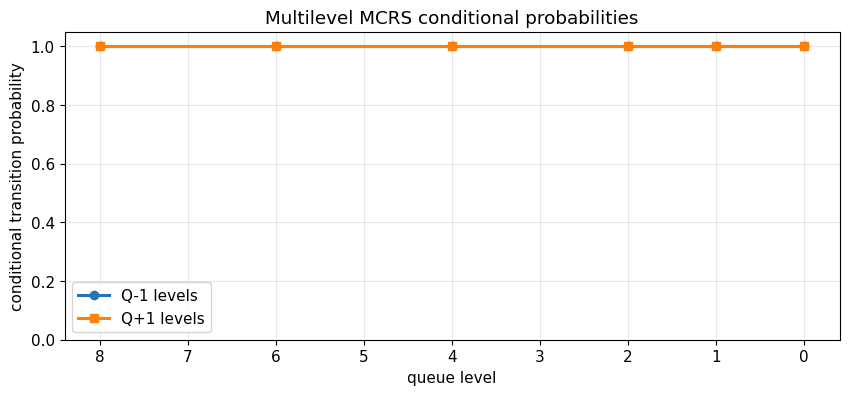

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(LEVELS, ml_same.level_probabilities, marker='o', linewidth=2.2, label='Q-1 levels')
ax.plot(LEVELS, ml_opp.level_probabilities, marker='s', linewidth=2.2, label='Q+1 levels')
ax.invert_xaxis()
ax.set_ylim(0, 1.05)
ax.set_xlabel('queue level')
ax.set_ylabel('conditional transition probability')
ax.set_title('Multilevel MCRS conditional probabilities')
ax.legend()
plt.show()


## Naive Ogata Monte Carlo comparison at matched particle budget

For a fair first comparison, the naive estimator uses the same trajectory-count budget as the multilevel estimator:

$$n_{naive}=n_{particles}\times |levels|.$$

We report CI width, CPU seconds, effective sample size, and Ogata acceptance/candidate ratios. This is not a perfect hardware-normalized budget, so the table also exposes events and candidates.

,side,method,probability,ci_width,cpu_seconds,effective_sample_size,n_events,n_candidates,acceptance_candidate_ratio
0,Q-1,Naive Ogata Monte Carlo,1.0,0.0,11.010720,1500.000000,10534,10817,0.973837
1,Q-1,Multilevel Markovian Conditional Restart Split...,1.0,0.0,1.981588,115.313653,1867,1910,0.977487
2,Q+1,Naive Ogata Monte Carlo,1.0,0.0,10.063977,1500.000000,10095,10349,0.975457
3,Q+1,Multilevel Markovian Conditional Restart Split...,1.0,0.0,1.631335,120.656371,1843,1889,0.975648


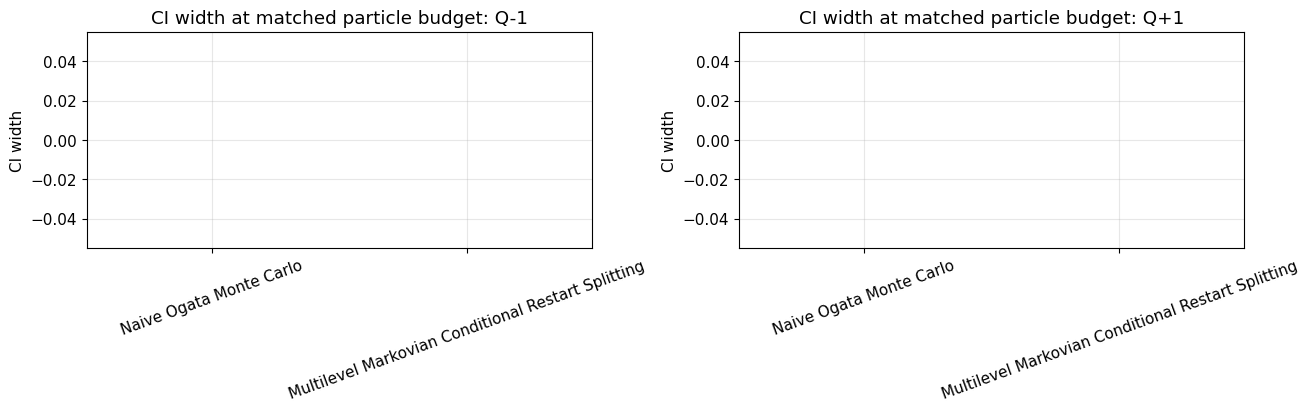

In [10]:
NAIVE_BUDGET = ML_N_PARTICLES * len(LEVELS)
naive_same = run_naive_depletion_monte_carlo(
    simulator=FourQueueHawkesSimulator(params_ml),
    initial_state=initial_ml,
    queue_index=-1,
    horizon=HORIZON_BOUNDARY,
    n_paths=NAIVE_BUDGET,
    rng=SEED + 7_000,
    burn_in=BURN_IN,
    queue_indices=QUEUE_INDICES,
)
naive_opp = run_naive_depletion_monte_carlo(
    simulator=FourQueueHawkesSimulator(params_ml),
    initial_state=initial_ml,
    queue_index=1,
    horizon=HORIZON_BOUNDARY,
    n_paths=NAIVE_BUDGET,
    rng=SEED + 7_100,
    burn_in=BURN_IN,
    queue_indices=QUEUE_INDICES,
)


def ci_width(ci):
    if ci is None:
        return np.nan
    return ci[1] - ci[0]

comparison_budget = pd.DataFrame([
    {
        'side': 'Q-1',
        'method': 'Naive Ogata Monte Carlo',
        'probability': naive_same.probability_estimate,
        'ci_width': ci_width(naive_same.confidence_interval),
        'cpu_seconds': naive_same.diagnostics['cpu_seconds'],
        'effective_sample_size': naive_same.diagnostics['effective_sample_size'],
        'n_events': naive_same.diagnostics['n_events'],
        'n_candidates': naive_same.diagnostics['n_candidates'],
        'acceptance_candidate_ratio': naive_same.diagnostics['acceptance_candidate_ratio'],
    },
    {
        'side': 'Q-1',
        'method': 'Multilevel Markovian Conditional Restart Splitting',
        'probability': ml_same.probability_estimate,
        'ci_width': ci_width(ml_same.diagnostics['confidence_interval_delta']),
        'cpu_seconds': ml_same.diagnostics['cpu_seconds'],
        'effective_sample_size': np.nanmin(ml_same.diagnostics['effective_sample_size_by_level']),
        'n_events': ml_same.diagnostics['n_events'],
        'n_candidates': ml_same.diagnostics['n_candidates'],
        'acceptance_candidate_ratio': ml_same.diagnostics['acceptance_candidate_ratio'],
    },
    {
        'side': 'Q+1',
        'method': 'Naive Ogata Monte Carlo',
        'probability': naive_opp.probability_estimate,
        'ci_width': ci_width(naive_opp.confidence_interval),
        'cpu_seconds': naive_opp.diagnostics['cpu_seconds'],
        'effective_sample_size': naive_opp.diagnostics['effective_sample_size'],
        'n_events': naive_opp.diagnostics['n_events'],
        'n_candidates': naive_opp.diagnostics['n_candidates'],
        'acceptance_candidate_ratio': naive_opp.diagnostics['acceptance_candidate_ratio'],
    },
    {
        'side': 'Q+1',
        'method': 'Multilevel Markovian Conditional Restart Splitting',
        'probability': ml_opp.probability_estimate,
        'ci_width': ci_width(ml_opp.diagnostics['confidence_interval_delta']),
        'cpu_seconds': ml_opp.diagnostics['cpu_seconds'],
        'effective_sample_size': np.nanmin(ml_opp.diagnostics['effective_sample_size_by_level']),
        'n_events': ml_opp.diagnostics['n_events'],
        'n_candidates': ml_opp.diagnostics['n_candidates'],
        'acceptance_candidate_ratio': ml_opp.diagnostics['acceptance_candidate_ratio'],
    },
])
display(comparison_budget)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout='constrained')
for side, ax in zip(['Q-1', 'Q+1'], axes):
    data = comparison_budget[comparison_budget['side'] == side]
    ax.bar(data['method'], data['ci_width'], color=['tab:blue', 'tab:green'])
    ax.set_title(f'CI width at matched particle budget: {side}')
    ax.set_ylabel('CI width')
    ax.tick_params(axis='x', rotation=20)
plt.show()


## Conclusion

The improved MCRS implementation now uses Hawkes burn-in, correct four-queue excitation labels, explicit success/recovery/timeout diagnostics, bootstrap confidence intervals for conditional $Q^{-2}$ means, a sensitivity sweep over $a_{cross}$, and a genuine multilevel splitting estimator over queue levels.

The stochastic dynamics were not changed: all improvements are estimator, checkpointing, and presentation changes around the existing Ogata-based simulator.